In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Connect or create the database
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [7]:
# Create table and insert sample data
cursor.execute("DROP TABLE IF EXISTS sales")
cursor.execute("""
    CREATE TABLE sales (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        product TEXT,
        quantity INTEGER,
        price REAL
    )
""")
sample_data = [
    ('Apples', 10, 0.5),
    ('Bananas', 20, 0.3),
    ('Oranges', 15, 0.6),
    ('Apples', 5, 0.5),
    ('Bananas', 10, 0.3),
    ('Oranges', 10, 0.6)
]
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()


In [9]:
# ---- Run SQL Queries ----

def run_query(title, query):
    print(f"\n--- {title} ---")
    df = pd.read_sql_query(query, conn)
    print(df)
    return df

In [11]:
# 1. Show all sales
run_query("All Sales Records", "SELECT * FROM sales")


--- All Sales Records ---
   id  product  quantity  price
0   1   Apples        10    0.5
1   2  Bananas        20    0.3
2   3  Oranges        15    0.6
3   4   Apples         5    0.5
4   5  Bananas        10    0.3
5   6  Oranges        10    0.6


,id,product,quantity,price
0,1,Apples,10,0.5
1,2,Bananas,20,0.3
2,3,Oranges,15,0.6
3,4,Apples,5,0.5
4,5,Bananas,10,0.3
5,6,Oranges,10,0.6


In [17]:
# 2. Total Quantity Sold
run_query("Total Quantity Sold", "SELECT SUM(quantity) AS total_quantity_sold FROM sales")


--- Total Quantity Sold ---
   total_quantity_sold
0                   70


,total_quantity_sold
0,70


In [15]:
# 3. Total Revenue
run_query("Total Revenue", "SELECT SUM(quantity * price) AS total_revenue FROM sales")


--- Total Revenue ---
   total_revenue
0           31.5


,total_revenue
0,31.5


In [19]:
# 4. Revenue by Product
df_revenue = run_query("Revenue by Product", """
    SELECT product, SUM(quantity * price) AS revenue
    FROM sales
    GROUP BY product
""")


--- Revenue by Product ---
   product  revenue
0   Apples      7.5
1  Bananas      9.0
2  Oranges     15.0


In [21]:
# 5. Top-Selling Product by Quantity
run_query("Top-Selling Product", """
    SELECT product, SUM(quantity) AS total_quantity
    FROM sales
    GROUP BY product
    ORDER BY total_quantity DESC
    LIMIT 1
""")


--- Top-Selling Product ---
   product  total_quantity
0  Bananas              30


,product,total_quantity
0,Bananas,30


In [23]:
# 6. Average Price per Product
run_query("Average Price per Product", """
    SELECT product, AVG(price) AS average_price
    FROM sales
    GROUP BY product
""")


--- Average Price per Product ---
   product  average_price
0   Apples            0.5
1  Bananas            0.3
2  Oranges            0.6


,product,average_price
0,Apples,0.5
1,Bananas,0.3
2,Oranges,0.6


In [25]:
# 7. Product-Wise Transaction Count
run_query("Transaction Count per Product", """
    SELECT product, COUNT(*) AS transaction_count
    FROM sales
    GROUP BY product
""")



--- Transaction Count per Product ---
   product  transaction_count
0   Apples                  2
1  Bananas                  2
2  Oranges                  2


,product,transaction_count
0,Apples,2
1,Bananas,2
2,Oranges,2


In [27]:
# 8. Revenue Per Transaction
run_query("Revenue Per Transaction", """
    SELECT id, product, quantity, price, (quantity * price) AS revenue
    FROM sales
""")



--- Revenue Per Transaction ---
   id  product  quantity  price  revenue
0   1   Apples        10    0.5      5.0
1   2  Bananas        20    0.3      6.0
2   3  Oranges        15    0.6      9.0
3   4   Apples         5    0.5      2.5
4   5  Bananas        10    0.3      3.0
5   6  Oranges        10    0.6      6.0


,id,product,quantity,price,revenue
0,1,Apples,10,0.5,5.0
1,2,Bananas,20,0.3,6.0
2,3,Oranges,15,0.6,9.0
3,4,Apples,5,0.5,2.5
4,5,Bananas,10,0.3,3.0
5,6,Oranges,10,0.6,6.0


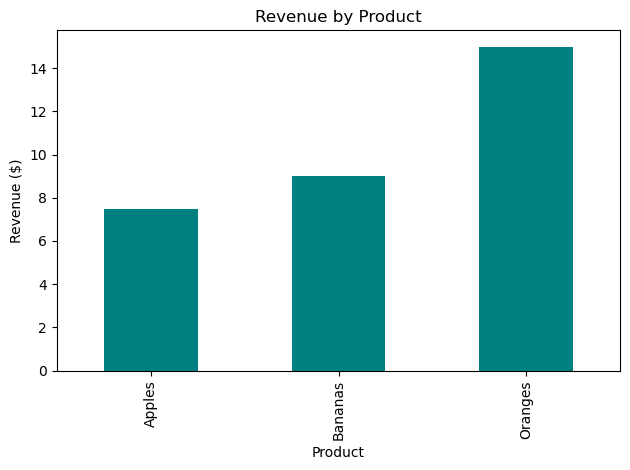

In [29]:
# ---- Plot Revenue by Product ----
df_revenue.plot(kind='bar', x='product', y='revenue', color='teal', legend=False)
plt.title("Revenue by Product")
plt.ylabel("Revenue ($)")
plt.xlabel("Product")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()

# Close DB connection
conn.close()